In [1]:
def print_set_sizes(train_X, train_y, test_X, test_y):
    print(f"""
    train_X: {train_X.shape}
    train_y: {train_y.shape}
    test_X: {test_X.shape}
    test_y: {test_y.shape}
    """)

In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np

"""
Testing should only be performed on the real dataset.
"""

BASEPATH = "/work/datasets/preprocessed/"

test_set = {
    "X": pd.read_csv(BASEPATH + "test_X.csv"),
    "y": pd.read_csv(BASEPATH + "test_y.csv")
}

real_train_set = {
    "X": pd.read_csv(BASEPATH + "real_X.csv"),
    "y": pd.read_csv(BASEPATH + "real_y.csv")
}

pseudoreal_train_set = {
    "X": pd.read_csv(BASEPATH + "pseudoreal_X.csv"),
    "y": pd.read_csv(BASEPATH + "pseudoreal_y.csv")
}

synthetic_train_set = {
    "X": pd.read_csv(BASEPATH + "synthetic_X.csv"),
    "y": pd.read_csv(BASEPATH + "synthetic_y.csv")
}


# Initialize LabelEncoder and transform labels
le = LabelEncoder()
test_set["y"] = pd.Series(le.fit_transform(test_set["y"]))
real_train_set["y"] = pd.Series(le.fit_transform(real_train_set["y"]))
pseudoreal_train_set["y"] = pd.Series(le.fit_transform(pseudoreal_train_set["y"]))
synthetic_train_set["y"] = pd.Series(le.fit_transform(synthetic_train_set["y"]))

# print label mappings
print(le.classes_)
print(real_train_set["X"].value_counts())


DATASETS = {
    "real": {
        "X": {
            "train": real_train_set["X"],
            "test": test_set["X"]
        },
        "y": {
            "train": real_train_set["y"],
            "test": test_set["y"]
        }
    },
    "pseudoreal": {
        "X": {
            "train": pseudoreal_train_set["X"],
            "test": test_set["X"]
        },
        "y": {
            "train": pseudoreal_train_set["y"],
            "test": test_set["y"]
        }
    },
    "real+synthetic": {
        "X": {
            "train": synthetic_train_set["X"],
            "test": test_set["X"]
        },
        "y": {
            "train": synthetic_train_set["y"],
            "test": test_set["y"]
        }
    }
}

DATASETS

['Insufficient_Weight' 'Normal_Weight' 'Obesity_Type_I' 'Obesity_Type_II'
 'Obesity_Type_III' 'Overweight_Level_I' 'Overweight_Level_II']
Age        Height     family_history_with_overweight  FAVC  SMOKE  SCC  CAEC  CALC  FCVC  NCP  CH2O  FAF  TUE  MTRANS_Automobile  MTRANS_Bike  MTRANS_Motorbike  MTRANS_Public_Transportation  MTRANS_Walking  Gender_Female  Gender_Male
-0.326657  -0.711087  0.0                             1.0   0.0    0.0  0.0   1.0   2.0   1.0  3.0   1.0  0.0  0.0                0.0          0.0               1.0                           0.0             0.0            1.0            2
-0.179134   0.004294  1.0                             1.0   0.0    0.0  1.0   1.0   2.0   3.0  2.0   1.0  1.0  0.0                0.0          0.0               1.0                           0.0             1.0            0.0            2
-0.031612   1.128464  1.0                             1.0   0.0    0.0  3.0   2.0   1.0   3.0  2.0   0.0  2.0  0.0                0.0          0.0    

{'real': {'X': {'train':           Age    Height  family_history_with_overweight  FAVC  SMOKE  SCC  \
   0   -0.769224 -1.937454                             1.0   1.0    0.0  0.0   
   1   -0.326657 -1.937454                             1.0   0.0    0.0  0.0   
   2   -0.769224 -1.222073                             1.0   1.0    0.0  0.0   
   3   -0.769224  0.617478                             1.0   1.0    0.0  0.0   
   4   -0.474179  1.128464                             1.0   1.0    0.0  0.0   
   ..        ...       ...                             ...   ...    ...  ...   
   233  0.410955  2.252634                             1.0   1.0    1.0  0.0   
   234  1.001044 -0.404495                             1.0   1.0    0.0  0.0   
   235 -0.621701  0.924070                             0.0   1.0    0.0  0.0   
   236 -0.326657 -0.813284                             1.0   1.0    0.0  0.0   
   237  1.001044  0.208689                             1.0   1.0    1.0  0.0   
   
        CAEC  

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, make_scorer
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np
from time import time

def train_evaluate_classifiers(X_train, y_train, X_test, y_test, random_state=42):
    """
    Train and evaluate multiple classifiers using 5-fold cross validation
    
    Parameters:
    -----------
    X_train : pd.DataFrame
        Training features
    y_train : pd.Series
        Training labels
    X_test : pd.DataFrame
        Test features
    y_test : pd.Series
        Test labels
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    dict : Dictionary containing results for each classifier
    """
    
    # Define classifiers
    classifiers = {
        'RandomForest': RandomForestClassifier(n_jobs=-1, random_state=random_state),
        'GradientBoosting': GradientBoostingClassifier(random_state=random_state),
        'SVM': SVC(random_state=random_state),
        'DecisionTree': DecisionTreeClassifier(random_state=random_state),
        'NaiveBayes': GaussianNB(),
        'KNN': KNeighborsClassifier(n_jobs=-1),
        'XGBoost': XGBClassifier(n_jobs=-1, random_state=random_state),
    }
    
    # Define scoring metrics
    scoring = {
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    }
    
    results = {}
    
    for name, clf in classifiers.items():
        print(f"Training {name} classifier...")
        # Start timing
        start_time = time()
        
        # Perform cross-validation
        cv_results = cross_validate(
            clf,
            X_train,
            y_train,
            cv=5,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=True
        )
        
        # Fit on full training data and evaluate on test set
        clf_fit = clf.fit(X_train, y_train)
        test_pred_encoded = clf.predict(X_test)
        
        test_scores = precision_recall_fscore_support(y_test.values, test_pred_encoded, average='macro')
        test_accuracy = accuracy_score(y_test.values, test_pred_encoded)
        
        # Store results
        results[name] = {
            'cv_accuracy': np.mean(cv_results['test_accuracy']),
            'cv_accuracy_std': np.std(cv_results['test_accuracy']),
            'cv_precision': np.mean(cv_results['test_precision_macro']),
            'cv_recall': np.mean(cv_results['test_recall_macro']),
            'cv_f1': np.mean(cv_results['test_f1_macro']),
            'test_accuracy': test_accuracy,
            'test_precision': test_scores[0],
            'test_recall': test_scores[1],
            'test_f1': test_scores[2],
            'training_time': time() - start_time,
            'fitted_model': clf_fit
        }
    
    return results

RESULTS = {}

# Test the function on both real and synthetic datasets
for dataset_name, dataset in DATASETS.items():
    print(f"\nEvaluating on {dataset_name} dataset:")
    
    # Prepare data
    X_train = dataset['X']['train']
    y_train = dataset['y']['train']
    X_test = dataset['X']['test']
    y_test = dataset['y']['test']

    print("Dataset sizes:")
    print(f"X_train: {X_train.shape}")
    print(f"y_train: {y_train.shape}")
    print(f"X_test: {X_test.shape}")
    print(f"y_test: {y_test.shape}")
    
    """
    # For synthetic dataset, use only the first 423 test samples to match real dataset

    if dataset_name == 'synthetic':
        X_test = X_test.iloc[:423]
        y_test = y_test.iloc[:423]
    """

    # Train and evaluate
    results = train_evaluate_classifiers(X_train, y_train, X_test, y_test)
    
    # Store results
    RESULTS[dataset_name] = results

    # Print results
    for clf_name, metrics in results.items():
        print(f"\n{clf_name}:")
        print(f"CV Accuracy: {metrics['cv_accuracy']:.3f} (±{metrics['cv_accuracy_std']:.3f})")
        print(f"Test Accuracy: {metrics['test_accuracy']:.3f}")
        print(f"Test F1-Score: {metrics['test_f1']:.3f}")
        print(f"Training Time: {metrics['training_time']:.2f} seconds")


Evaluating on real dataset:
Dataset sizes:
X_train: (238, 20)
y_train: (238,)
X_test: (239, 20)
y_test: (239,)
Training RandomForest classifier...
/root/venv/lib/python3.10/site-packages/sklearn/model_selection/_split.py:684: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/root/venv/lib/python3.10/site-packages/sklearn/metrics/_classi

In [4]:
markdown_text = "# Baseline Classifier Evaluation Results\n\n"
markdown_text += """
> The following table shows the results of the baseline classifiers on the real and synthetic datasets.
> The results are based on 5-fold cross-validation with default parameters.
> The results are displayed in descending order of F1-Score.

"""

# make a markdown table from the results
for dataset_name, results in RESULTS.items():
    markdown_text += f"## {dataset_name.capitalize()} Dataset\n\n"
    
    # Create table header
    markdown_text += "| Classifier | CV Accuracy | Test Accuracy | Test F1-Score | Training Time (s) | Efficiency (F1/s) |\n"
    markdown_text += "|------------|-------------|---------------|---------------|------------------| ------------------ |\n"
    
    # Order by f1-score
    results_ord = {k: v for k, v in sorted(results.items(), key=lambda item: item[1]['test_f1'], reverse=True)}

    # Add each classifier's results as a row
    for clf_name, metrics in results_ord.items():
        training_time_to_f1_ratio = metrics['test_f1'] / metrics['training_time']
        markdown_text += f"| {clf_name} | {metrics['cv_accuracy']:.3f} (±{metrics['cv_accuracy_std']:.3f}) | "
        markdown_text += f"{metrics['test_accuracy']:.3f} | {metrics['test_f1']:.3f} | {metrics['training_time']:.2f} | {training_time_to_f1_ratio:.2f} |\n"
    markdown_text += "\n"  # Add space between dataset tables

# Write to file
with open('classification_results.md', 'w') as f:
    f.write(markdown_text)

print("Results have been written to classification_results.md")

Results have been written to classification_results.md


/root/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 1200x800 with 0 Axes>

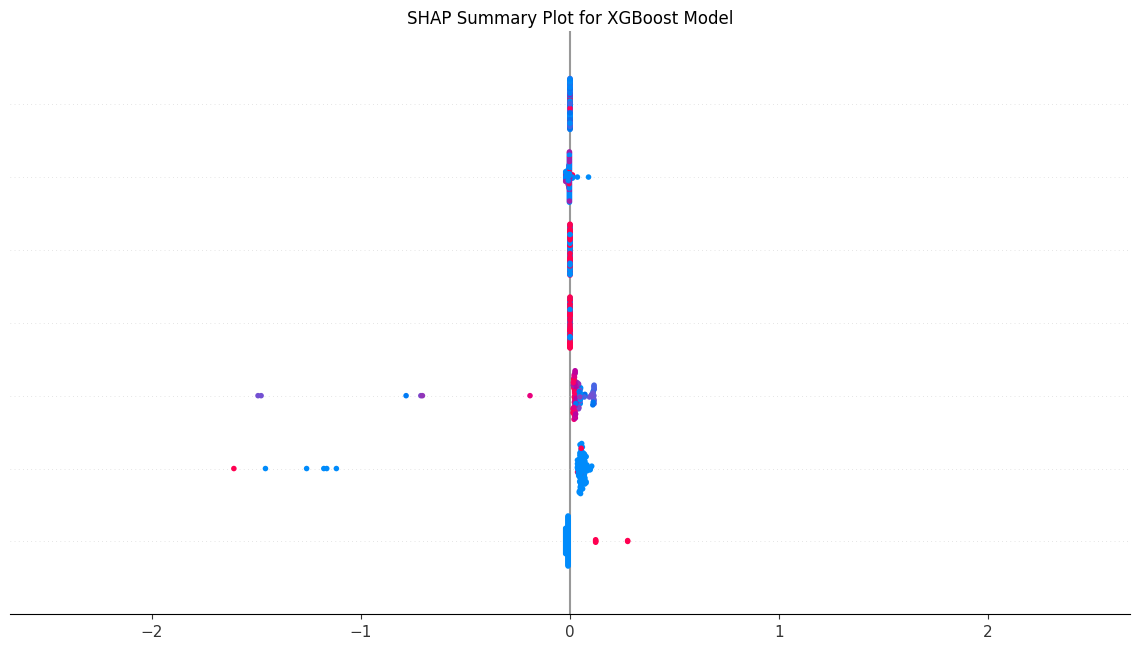

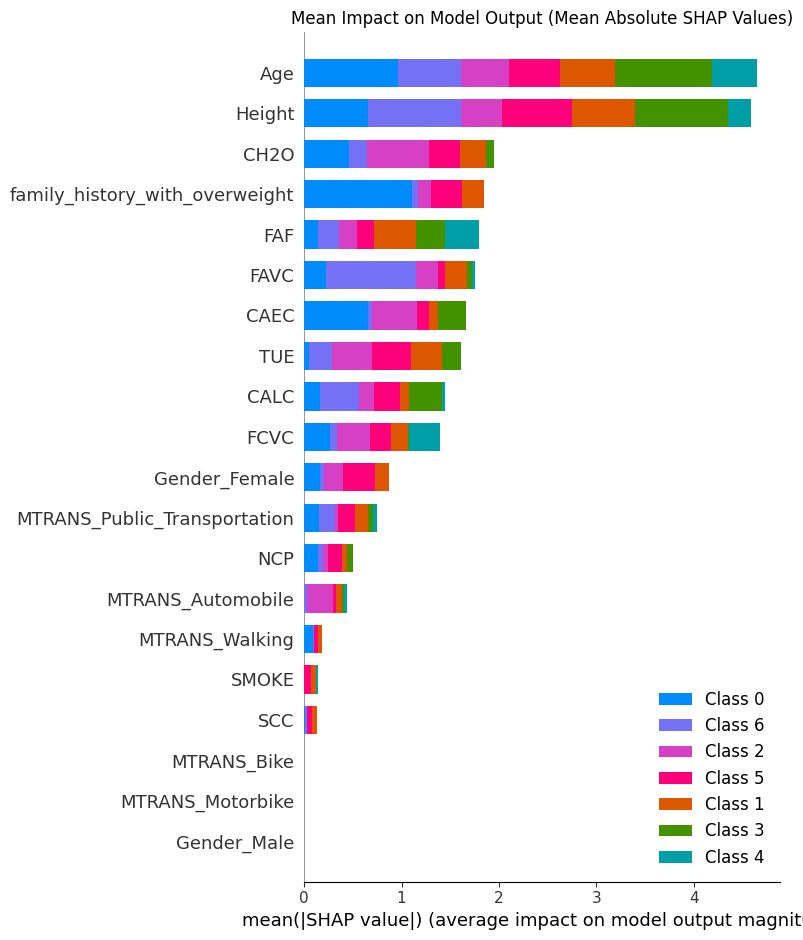

In [5]:
import shap
import matplotlib.pyplot as plt

# Get the XGBoost model and sample data
xgb_model = RESULTS['real']['XGBoost']['fitted_model']

# Create a SHAP explainer for the model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for a subset of training data (100 samples for visualization)
shap_values = explainer.shap_values(X_train[:100])

# Create summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_train[:100], feature_names=X_train.columns, show=False)
plt.title('SHAP Summary Plot for XGBoost Model')
plt.tight_layout()
plt.show()

# Bar plot of mean absolute SHAP values
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_train[:100], feature_names=X_train.columns, plot_type="bar", show=False)
plt.title('Mean Impact on Model Output (Mean Absolute SHAP Values)')
plt.tight_layout()
plt.show()

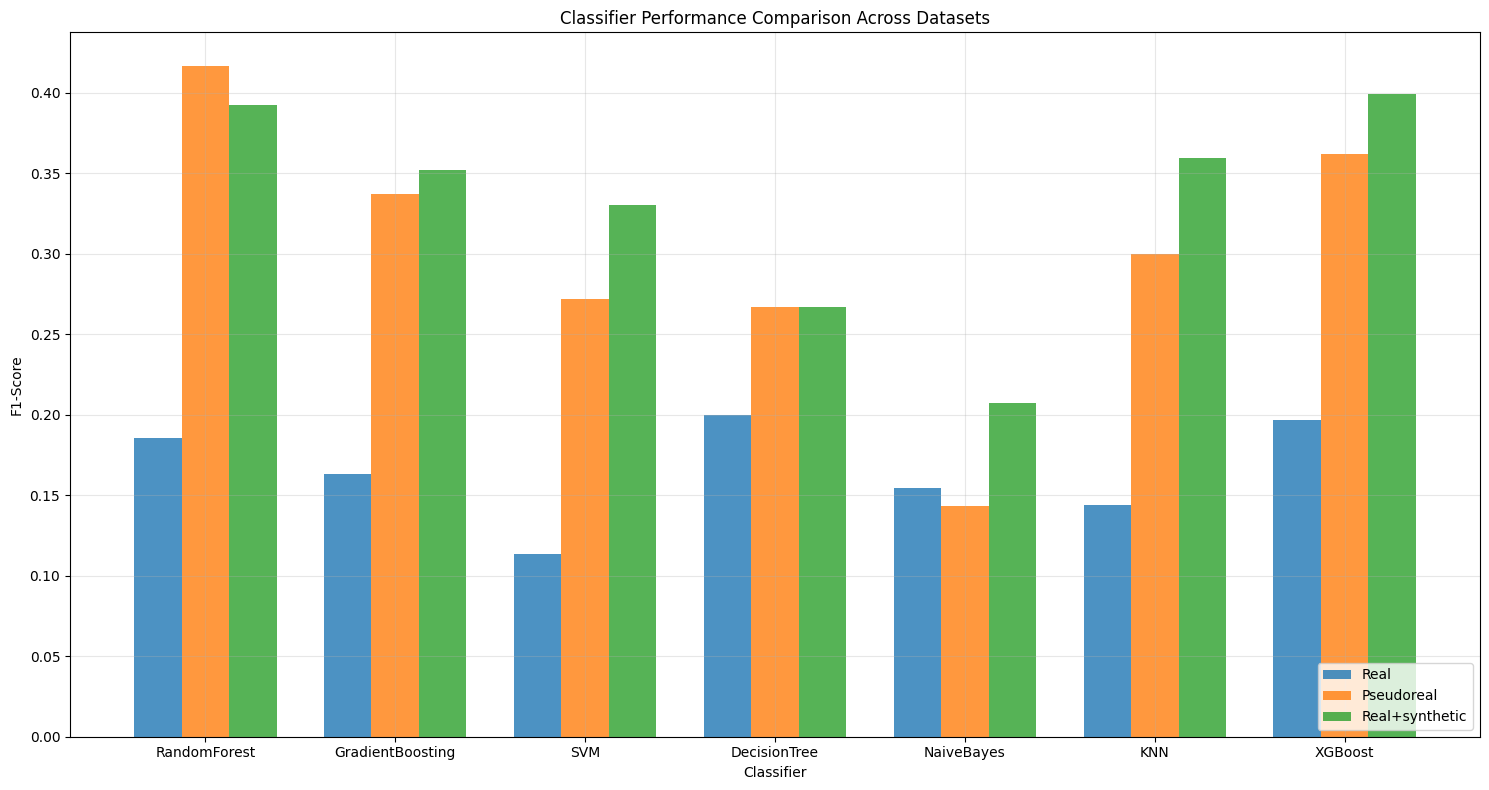

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dataframe from the results
data = []
for dataset_name, results in RESULTS.items():
    for clf_name, metrics in results.items():
        data.append({
            'Dataset': dataset_name.capitalize(),
            'Classifier': clf_name,
            'CV Accuracy': metrics['cv_accuracy'],
            'Test Accuracy': metrics['test_accuracy'],
            'Test F1-Score': metrics['test_f1']
        })

df_metrics = pd.DataFrame(data)

# Create a grouped bar plot
plt.figure(figsize=(15, 8))
metrics = ['CV Accuracy', 'Test Accuracy', 'Test F1-Score']
x = np.arange(len(df_metrics['Classifier'].unique()))
width = 0.25

for i, dataset in enumerate(df_metrics['Dataset'].unique()):
    dataset_data = df_metrics[df_metrics['Dataset'] == dataset]
    plt.bar(x + i*width, dataset_data['Test F1-Score'], 
            width, label=f'{dataset}', alpha=0.8)

plt.xlabel('Classifier')
plt.ylabel('F1-Score')
plt.title('Classifier Performance Comparison Across Datasets')
plt.xticks(x + width, df_metrics['Classifier'].unique(), ha='center')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [1]:
# Evaluate the RandomForest model on real+synthetic dataset
# Shows confusion matrix 
# Showsand per-class F1/precision/recall (imbalanced)

def evaluate_model_with_report(model, X_test, y_test, class_names):
    from sklearn.metrics import confusion_matrix, classification_report
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    return pd.DataFrame(report).transpose()

model = RESULTS["real+synthetic"]["RandomForest"]["fitted_model"]
X_test = DATASETS["real+synthetic"]["X"]["test"]
y_test = DATASETS["real+synthetic"]["y"]["test"]

class_names = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I',
               'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

report_df = evaluate_model_with_report(model, X_test, y_test, class_names)
display(report_df)



NameError: name 'RESULTS' is not defined

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a441f35e-4b4c-4c50-b56a-1aea6b800ed8' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>